# Проект

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import random

import optuna
import shap
import mlflow

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.impute import IterativeImputer
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from darts import TimeSeries
from darts.metrics import wmape

import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = None
sklearn.set_config(transform_output='pandas')
pd.set_option('display.max_columns', None)

np.random.seed(42)
random.seed(42)

c:\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("rossmann_sales_forecast")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1784971560656, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784971560656, lifecycle_stage='active', name='rossmann_sales_forecast', tags={}, trace_location=None, workspace='default'>

# Достаем данные

In [3]:
path = kagglehub.dataset_download("shahpranshu27/rossman-store-sales")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\arutg\.cache\kagglehub\datasets\shahpranshu27\rossman-store-sales\versions\1


In [4]:
train = pd.read_csv(path + '/rossmann-store-sales/train.csv', low_memory=False, parse_dates=['Date'])
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store = pd.read_csv(path + '/rossmann-store-sales/store.csv', low_memory=False)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
store[['Promo2SinceWeek', 'Promo2SinceYear']] = store[['Promo2SinceWeek', 'Promo2SinceYear']].fillna(0)

In [7]:
cat_features = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'DayOfWeek']

## Объединим train и store в один датафрейм для обучения

In [8]:
df = train.merge(store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NaN


In [9]:
df = df.sort_values(by='Date').reset_index(drop=True)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1,379,2,2013-01-01,0,0,0,0,a,1,d,a,6630.0,NaN,NaN,0,0.0,0.0,NaN
2,378,2,2013-01-01,0,0,0,0,a,1,a,c,2140.0,8.0,2012.0,0,0.0,0.0,NaN
3,377,2,2013-01-01,0,0,0,0,a,1,a,c,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov"
4,376,2,2013-01-01,0,0,0,0,a,1,a,a,160.0,8.0,2012.0,0,0.0,0.0,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

# EDA

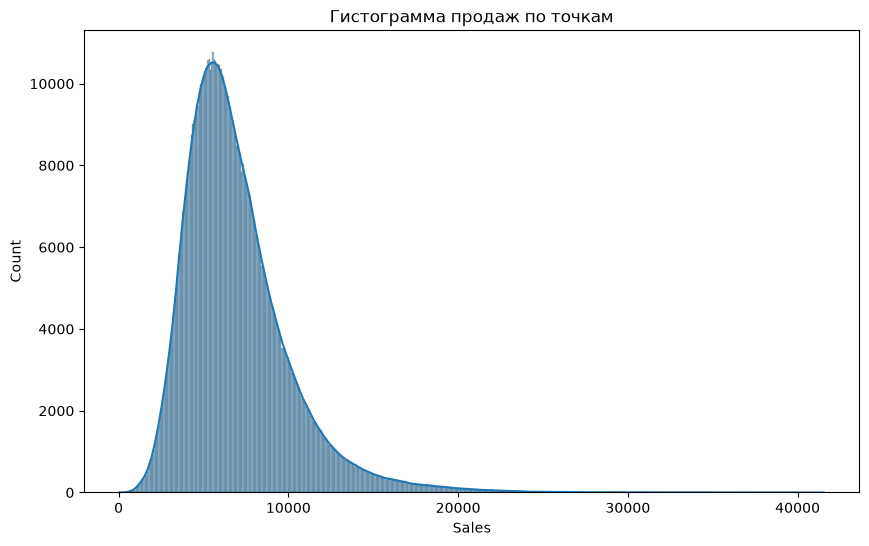

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df[df['Sales'] > 0], x='Sales', kde=True, ax=ax)
ax.set_title('Гистограмма продаж по точкам')
plt.show()

В основном за день один магазин зарабатывает около 8к евро

In [12]:
print(f"Коэф. ассиметрии = {df[df['Sales'] > 0]['Sales'].skew().item():.3f}. Пик смещен влево")
print(f"Коэф. эксцесса = {df[df['Sales'] > 0]['Sales'].kurt().item():.3f}. Пик острый")

Коэф. ассиметрии = 1.595. Пик смещен влево
Коэф. эксцесса = 4.854. Пик острый


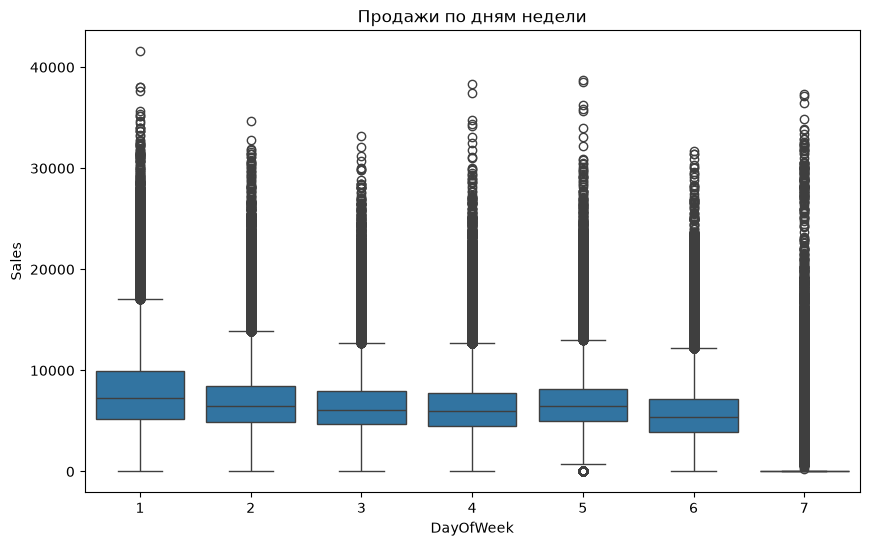

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='DayOfWeek', y='Sales', ax=ax)
ax.set_title('Продажи по дням недели')
plt.show()

Основная доля продаж приходится на воскресенье и понедельник

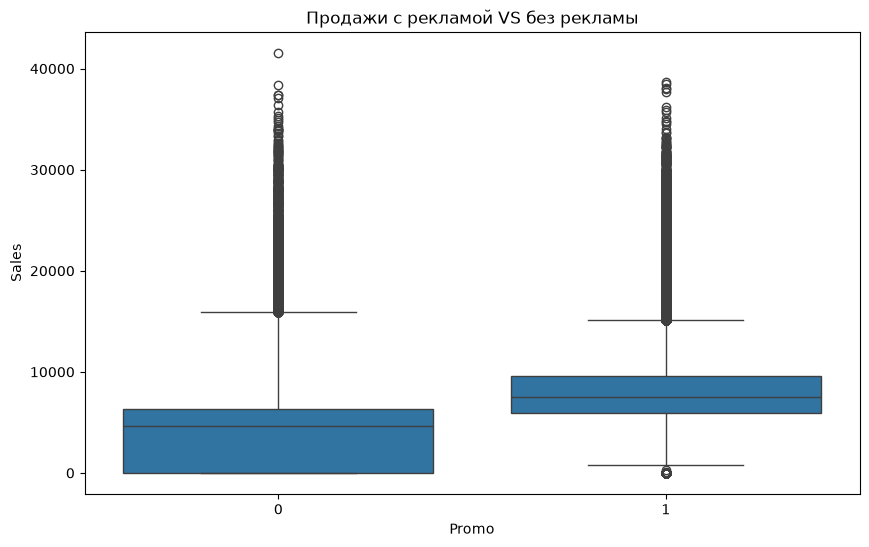

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Promo', y='Sales', ax=ax)
ax.set_title('Продажи с рекламой VS без рекламы')
plt.show()

Реклама позитивно влияет на продажи

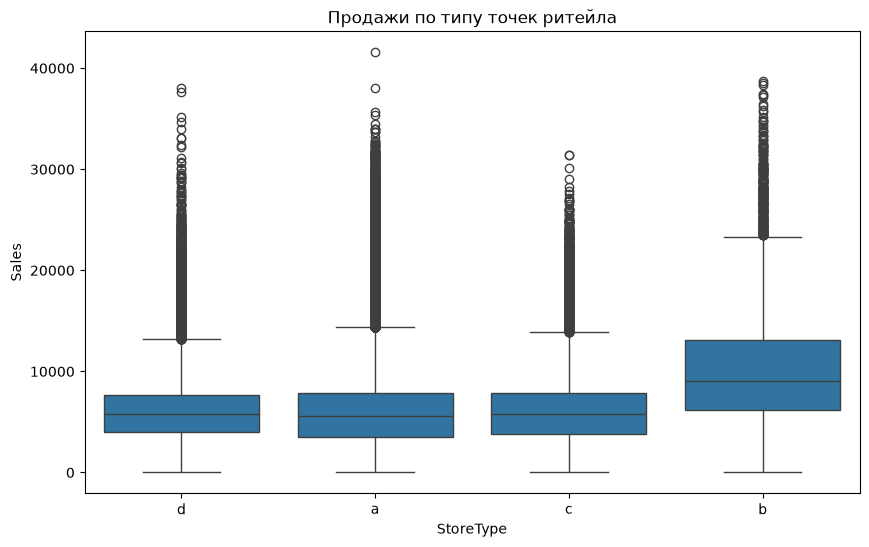

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='StoreType', y='Sales', ax=ax)
ax.set_title('Продажи по типу точек ритейла')
plt.show()

Точки ритейла типа b лучше всего продаются

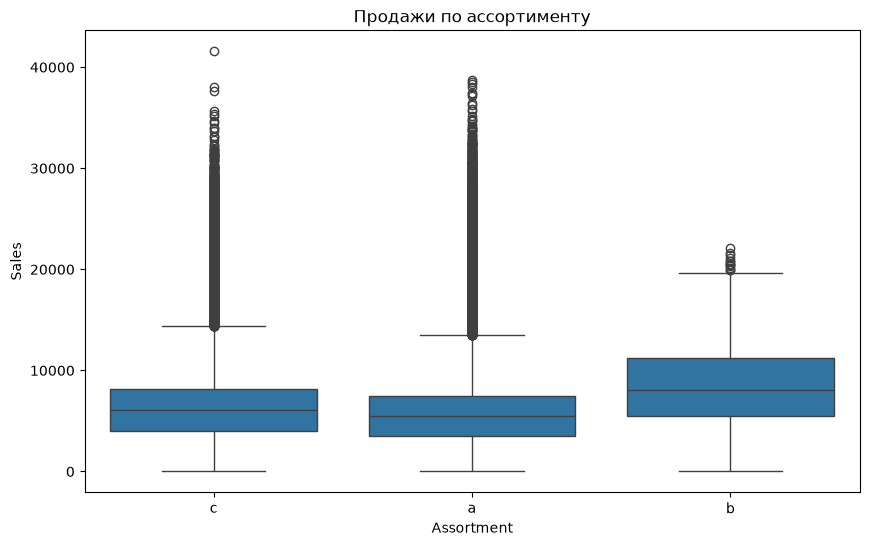

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Assortment', y='Sales', ax=ax)
ax.set_title('Продажи по ассортименту')
plt.show()

Ассортимент b лучше всего продается

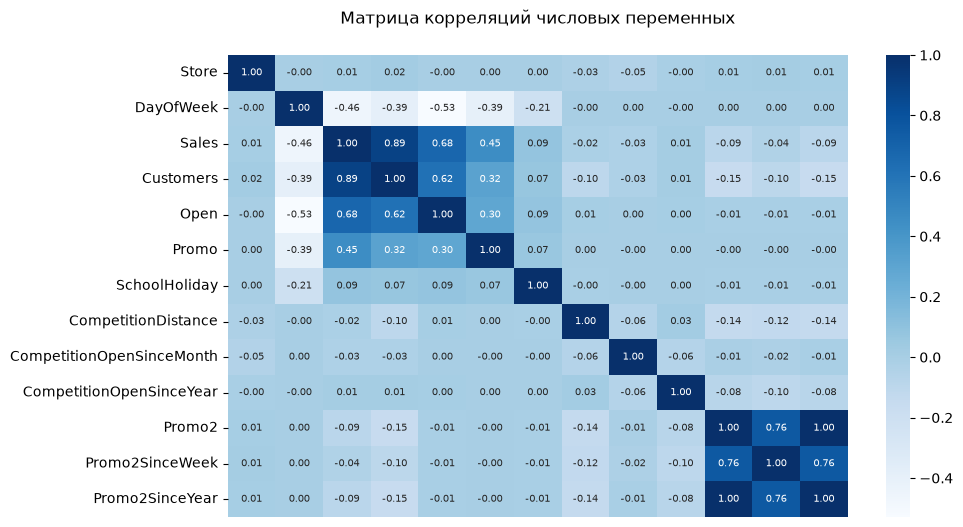

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={"size": 7},
    xticklabels=False,
    ax=ax
)
ax.set_title('Матрица корреляций числовых переменных', y=1.05)
plt.show()

Видно, что Customers и Promo сильно коррелируют с таргетом

# Feature Engineering

## Фичи по дате

In [18]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfMonth'] = df['Date'].dt.day
df['DayOfYear'] = df['Date'].dt.day_of_year

## Фичи по конкурентам
Сколько месяцев на текущий момент функционирует конкурент. От текущей даты вычитаем дату открытия и переводим в месяцы

In [19]:
competitors_dates = {
    'year': df['CompetitionOpenSinceYear'],
    'month': df['CompetitionOpenSinceMonth'],
    'day': 1
}

df_dates = pd.to_datetime(competitors_dates)
diff = (df['Date'].dt.to_period('M') - df_dates.dt.to_period('M')).apply(lambda x: x.n if pd.notna(x) else np.nan)

df['CompetitionMonths'] = diff
df = df.drop(columns=['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'])

## Бинарная фича из PromoIntertest

In [20]:
months_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10,
'Nov': 11, 'Dec': 12}

def func_filter(row):
    if isinstance(row, list):
        return [months_mapping[x] for x in row]
    else:
        return [0]

In [21]:
df['PromoInterval'] = df['PromoInterval'].str.split(',').apply(func_filter)

In [22]:
df['Promo2Exists'] = df.apply(lambda row: row['Month'] in row['PromoInterval'], axis=1)

In [23]:
mask = df['Promo2'] == 1
years = df[mask]['Promo2SinceYear'].astype(int).astype(str)
weeks = df[mask]['Promo2SinceWeek'].astype(int).astype(str)
date_strings = years + '-' + weeks + '-1'

df.loc[mask, 'Promo2StartDate'] = pd.to_datetime(date_strings, format='%Y-%W-%w')

In [24]:
df['IsPromo2Month'] = (df['Promo2']) & (df['Date'] >= df['Promo2StartDate']) & (df['Promo2Exists'])

In [25]:
df = df.drop(columns=['PromoInterval', 'Promo2Exists', 'Promo2StartDate'])

## Скользящие характеристики

In [26]:
df['PromoMean7'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=7).mean())
df['PromoMean28'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=28).mean())

In [27]:
df['SchoolHolidaySum7'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=7).sum())
df['SchoolHolidaySum28'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=28).sum())

## Типы данных

In [28]:
df['StoreType'] = df['StoreType'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4})
df['Assortment'] = df['Assortment'].map({'a': 1, 'b': 2, 'c': 3})
df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3})
df = df.drop(columns=['Customers'])

# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [29]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [30]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Пропуски в данных

In [31]:
missing = train_df.isna().sum()
missing[missing > 0]

CompetitionDistance      2234
CompetitionMonths      275204
PromoMean7               7805
PromoMean28             31220
SchoolHolidaySum7        7805
SchoolHolidaySum28      31220
dtype: int64

## Анализ кластеров NaN

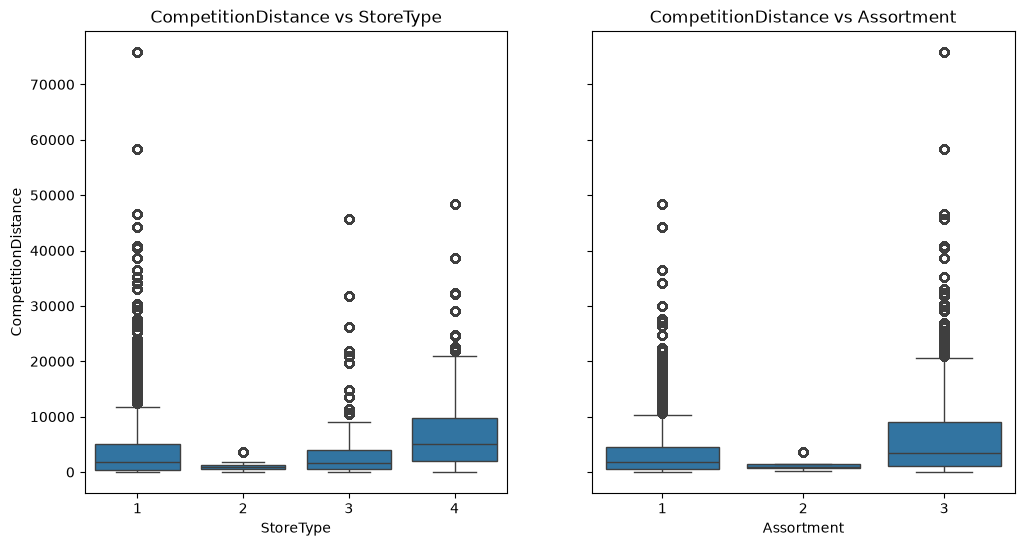

In [32]:
no_competitors = train_df[pd.notna(train_df['CompetitionDistance'])]
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))

sns.boxplot(no_competitors, x='StoreType', y='CompetitionDistance', ax=ax[0])
ax[0].set_title("CompetitionDistance vs StoreType")

sns.boxplot(no_competitors, x='Assortment', y='CompetitionDistance', ax=ax[1])
ax[1].set_title("CompetitionDistance vs Assortment")

plt.show()

In [33]:
train_clusters = train_df.copy()
group_medians = train_clusters.groupby(['StoreType', 'Assortment'])[['CompetitionDistance', 'CompetitionMonths']].transform('median')
global_medians = train_clusters[['CompetitionMonths']].median()

In [34]:
train_clusters[['CompetitionDistance', 'CompetitionMonths']] = train_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
train_clusters[['CompetitionMonths']] = train_clusters[['CompetitionMonths']].fillna(global_medians)

In [35]:
val_clusters = val_df.copy()
val_clusters[['CompetitionDistance', 'CompetitionMonths']] = val_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
val_clusters[['CompetitionMonths']] = val_clusters[['CompetitionMonths']].fillna(global_medians)

In [36]:
X_train, y_train = train_clusters.drop(columns=['Sales', 'Date']), train_clusters['Sales']
X_val, y_val = val_clusters.drop(columns=['Sales', 'Date']), val_clusters['Sales']

In [37]:
mlflow.start_run(run_name='impute_group_median')

<ActiveRun: >

In [38]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [39]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9314111480082972
MSE score = 1069643.593041187
RMSE score = 1034.2357531245896
WAPE score = 11.388225715533563


In [40]:
mlflow.log_param('imputer', 'group_median_fillna')
mlflow.log_metric('R2', r2)
mlflow.log_metric('MSE', mse)
mlflow.log_metric('RMSE', rmse)
mlflow.log_metric('WAPE', wape)
mlflow.end_run()

🏃 View run impute_group_median at: http://localhost:5000/#/experiments/1/runs/8ca6bd85b3ae4ccea03a839a5a629b1e
🧪 View experiment at: http://localhost:5000/#/experiments/1


## IterativeImputer / BayesianRidge

In [41]:
mlflow.start_run(run_name='impute_iterative_bayesian_ridge')

<ActiveRun: >

In [42]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

In [44]:
br_impute = IterativeImputer(max_iter=3, random_state=42)
X_train_br = pd.DataFrame(scaler.inverse_transform(br_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_br = pd.DataFrame(scaler.inverse_transform(br_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

In [45]:
X_train_br['CompetitionMonths'] = X_train_br['CompetitionMonths'].astype(int)
X_train_br['SchoolHolidaySum7'] = X_train_br['SchoolHolidaySum7'].astype(int)
X_train_br['SchoolHolidaySum28'] = X_train_br['SchoolHolidaySum28'].astype(int)

X_val_br['CompetitionMonths'] = X_val_br['CompetitionMonths'].astype(int)
X_val_br['SchoolHolidaySum7'] = X_val_br['SchoolHolidaySum7'].astype(int)
X_val_br['SchoolHolidaySum28'] = X_val_br['SchoolHolidaySum28'].astype(int)

In [46]:
X_train = train_df[cat_features + bool_features].join(X_train_br).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_br).reindex(columns=target_columns)
y_val = val_df['Sales']

In [47]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [48]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9318323522668894
MSE score = 1063074.909888138
RMSE score = 1031.0552409488728
WAPE score = 11.379106533527867


In [49]:
mlflow.log_param('imputer', 'iterative_bayesian_ridge')
mlflow.log_metric('R2', r2)
mlflow.log_metric('MSE', mse)
mlflow.log_metric('RMSE', rmse)
mlflow.log_metric('WAPE', wape)
mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
mlflow.sklearn.log_model(br_impute, 'imputer', serialization_format='pickle')
mlflow.end_run()

2026/07/25 23:51:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/25 23:51:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/25 23:51:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/25 23:51:21 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/25 23:51:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/25 23:51:21 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run impute_iterative_bayesian_ridge at: http://localhost:5000/#/experiments/1/runs/df5e33bf3f1546669a1744ddd938409f
🧪 View experiment at: http://localhost:5000/#/experiments/1


## IterativeImputer / SVR

In [50]:
mlflow.start_run(run_name='impute_iterative_svr')

<ActiveRun: >

In [51]:
%%time

svr_impute = IterativeImputer(estimator=SVR(max_iter=500, cache_size=1000), max_iter=3, random_state=42)
X_train_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

CPU times: total: 26min 40s
Wall time: 28min 16s


In [52]:
X_train_svr['CompetitionMonths'] = X_train_svr['CompetitionMonths'].astype(int)
X_train_svr['SchoolHolidaySum7'] = X_train_svr['SchoolHolidaySum7'].astype(int)
X_train_svr['SchoolHolidaySum28'] = X_train_svr['SchoolHolidaySum28'].astype(int)

X_val_svr['CompetitionMonths'] = X_val_svr['CompetitionMonths'].astype(int)
X_val_svr['SchoolHolidaySum7'] = X_val_svr['SchoolHolidaySum7'].astype(int)
X_val_svr['SchoolHolidaySum28'] = X_val_svr['SchoolHolidaySum28'].astype(int)

In [53]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [54]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [55]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9311604488815317
MSE score = 1073553.247554113
RMSE score = 1036.124146786529
WAPE score = 11.42405094418677


In [56]:
mlflow.log_param('imputer', 'iterative_svr')
mlflow.log_metric('R2', r2)
mlflow.log_metric('MSE', mse)
mlflow.log_metric('RMSE', rmse)
mlflow.log_metric('WAPE', wape)
mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
mlflow.sklearn.log_model(svr_impute, 'imputer', serialization_format='pickle')
mlflow.end_run()

2026/07/26 00:19:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 00:19:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 00:19:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 00:19:55 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/26 00:19:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 00:19:55 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run impute_iterative_svr at: http://localhost:5000/#/experiments/1/runs/86d2541f037c4e1e8809e019164d1c2e
🧪 View experiment at: http://localhost:5000/#/experiments/1


Лучшим оказался ItertativeImputer на Bayesian Ridge

In [57]:
X_train = train_df[cat_features + bool_features].join(X_train_br).reindex(columns=target_columns)
y_train = train_df['Sales']

In [58]:
X_val = val_df[cat_features + bool_features].join(X_val_br).reindex(columns=target_columns)
y_val = val_df['Sales']

In [59]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [60]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

# Обучение

In [61]:
def get_period_config(n_weeks: int) -> dict:
    PERIOD_CONFIG = {
        1:  {'lags': [1, 2, 3, 4], 'windows': [4, 12], 'pct_change': [4, 12]},
        2:  {'lags': [1, 2, 3],    'windows': [2, 6],  'pct_change': [2, 6]},
        4:  {'lags': [1, 2, 3],    'windows': [3, 6],  'pct_change': [1, 3]},
        6:  {'lags': [1, 2],       'windows': [2, 4],  'pct_change': [1, 2]},
        12: {'lags': [1, 2],       'windows': [2, 3],  'pct_change': [1, 2]},
    }

    return PERIOD_CONFIG[n_weeks]

In [62]:
def add_target_features(data: pd.DataFrame, n_weeks: int) -> pd.DataFrame:
    data = data.sort_values(['Store', 'Date'])
    cfg = get_period_config(n_weeks)

    for lag in cfg['lags']:
        data[f'SalesLag{lag}'] = data.groupby('Store')['Sales'].shift(lag)

    for window in cfg['windows']:
        data[f'SalesMean{window}'] = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).mean())
        data[f'SalesStd{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).std())
        data[f'SalesMin{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).min())
        data[f'SalesMax{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).max())

    for periods in cfg['pct_change']:
        weeks_back = periods * n_weeks
        data[f'SalesPctChange{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.pct_change(periods).replace(np.inf, np.nan)
        )
        data[f'SalesDiff{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.diff(periods)
        )

    return data

In [63]:
def get_target_feature_cols(n_weeks: int) -> list[str]:
    cfg = get_period_config(n_weeks)
    cols = [f'SalesLag{lag}' for lag in cfg['lags']]
    for w in cfg['windows']:
        cols += [f'SalesMean{w}', f'SalesStd{w}', f'SalesMin{w}', f'SalesMax{w}']
    for periods in cfg['pct_change']:
        cols += [f'SalesPctChange{periods * n_weeks}w', f'SalesDiff{periods * n_weeks}w']
    return cols

In [64]:
def aggregate_bucket(full_df: pd.DataFrame, n_weeks: int, agg_dict: dict) -> pd.DataFrame:
    tmp = full_df.copy()
    tmp['WeekNum'] = tmp['Week'].rank(method='dense').astype(int) - 1
    tmp['Bucket'] = tmp['WeekNum'] // n_weeks
    tmp = tmp.drop(columns=['WeekNum'])

    bucket_df = tmp.groupby(['Store', 'Bucket']).agg(agg_dict)
    bucket_df['n_days'] = tmp.groupby(['Store', 'Bucket'])['Date'].count()
    bucket_df = bucket_df[bucket_df['n_days'] == n_weeks * 7]
    bucket_df = bucket_df.drop(columns=['n_days'])

    return bucket_df.reset_index()

In [65]:
def train_model(
    model: LGBMRegressor | CatBoostRegressor,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):
    is_catboost = isinstance(model, CatBoostRegressor)
    feature_cols = get_target_feature_cols(n_weeks)
    drop_cols = ['Sales', 'Date', 'Bucket']
    true_sales = data.set_index(['Store', 'Bucket'])['Sales']

    train = data[data['Date'] <= cutoff]
    X_train = train.drop(columns=drop_cols).dropna(subset=feature_cols)
    y_train = train.loc[X_train.index, 'Sales']

    if is_catboost:
        X_train[cat_features] = X_train[cat_features].astype(str)
        model.fit(X_train, y_train, cat_features=cat_features)
    else:
        model.fit(X_train, y_train, categorical_feature=cat_features)

    horizon = np.sort(data[data['Date'] > cutoff]['Bucket'].unique())[:n_steps]
    predicted_index = []

    for period in horizon:
        mask = data['Bucket'] == period
        X_step = data.loc[mask].drop(columns=drop_cols).dropna(subset=feature_cols)

        if is_catboost:
            X_step[cat_features] = X_step[cat_features].astype(str)

        y_pred = model.predict(X_step)
        data.loc[X_step.index, 'Sales'] = y_pred
        predicted_index.extend(X_step.index)

        data = add_target_features(data, n_weeks)

    pred_final = data.loc[predicted_index].set_index(['Store', 'Bucket'])['Sales']
    real_final = true_sales.loc[pred_final.index]

    actual = TimeSeries.from_values(real_final)
    predicted = TimeSeries.from_values(pred_final)

    return X_train, wmape(actual, predicted)

In [66]:
def objective(
    trial: optuna.trial.Trial,
    model_type: str,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):

    if model_type == 'lgbm':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        n_estimators = trial.suggest_int('n_estimators', 500, 2500)
        min_child_samples = trial.suggest_int('min_child_samples', 50, 500)
        num_leaves = trial.suggest_int('num_leaves', 200, 1200)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-3, 10, log=True)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)

        model = LGBMRegressor(
            learning_rate=lr,
            n_estimators=n_estimators,
            min_child_samples=min_child_samples,
            num_leaves=num_leaves,
            reg_lambda=reg_lambda,
            colsample_bytree=colsample_bytree,
            random_state=42, n_jobs=-1, verbosity=-1
        )

    elif model_type == 'cb':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        iterations = trial.suggest_int('iterations', 300, 1200)
        depth = trial.suggest_int('depth', 4, 10)
        bag_temp = trial.suggest_float('bagging_temperature', 0, 10)
        l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 4, 10)
        random_strength = trial.suggest_float('random_strength', 0, 10)
        subsample = trial.suggest_float('subsample', 0.5, 1.0)

        model = CatBoostRegressor(
            learning_rate=lr,
            iterations=iterations,
            depth=depth,
            bagging_temperature=bag_temp,
            l2_leaf_reg=l2_leaf_reg,
            random_strength=random_strength,
            subsample=subsample,
            has_time=True, random_state=42, verbose=False
        )

    _, score = train_model(model, data.copy(), n_steps, n_weeks)

    return score

In [67]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

In [68]:
first_cols = ['StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
              'CompetitionMonths', 'DayOfMonth', 'DayOfWeek', 'DayOfYear', 'Month', 'Year']
max_cols = ['Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'IsPromo2Month']
mean_cols = ['PromoMean7', 'PromoMean28', 'SchoolHolidaySum7', 'SchoolHolidaySum28']

In [69]:
agg_dict = {'Date': 'min', 'Sales': 'sum'}
agg_dict.update({c: 'first' for c in first_cols})
agg_dict.update({c: 'max' for c in max_cols})
agg_dict.update({c: 'mean' for c in mean_cols})

In [70]:
with mlflow.start_run(run_name='preprocessing_with_outliers') as prep_run:
    mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
    mlflow.sklearn.log_model(br_impute, 'imputer', serialization_format='pickle')
    mlflow.log_dict(
        {
            'cat_features': cat_features,
            'num_features': list(num_features),
            'target_columns': list(target_columns),
            'agg_dict': {k: (v if isinstance(v, str) else str(v)) for k, v in agg_dict.items()},
            'cutoff': str(cutoff),
        },
        'pipeline_metadata.json'
    )
    preprocessing_with_outliers_run_id = prep_run.info.run_id

2026/07/26 00:19:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 00:19:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 00:20:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 00:20:00 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/26 00:20:00 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 00:20:00 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run preprocessing_with_outliers at: http://localhost:5000/#/experiments/1/runs/03c4ea5edfb34d19b9728286996ef2d6
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по неделе вперед

In [71]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [72]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [73]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [74]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-26 00:20:07,605] A new study created in memory with name: no-name-c1d75b09-f8b6-499b-8fc1-4c5bfeed7e12
[I 2026-07-26 00:21:34,063] Trial 0 finished with value: 0.6211568354698944 and parameters: {'learning_rate': 0.007319719844542636, 'n_estimators': 756, 'min_child_samples': 89, 'num_leaves': 874, 'reg_lambda': 0.006002626964010272, 'colsample_bytree': 0.8886186409407881}. Best is trial 0 with value: 0.6211568354698944.
[I 2026-07-26 00:22:44,677] Trial 1 finished with value: 0.805140743850543 and parameters: {'learning_rate': 0.04611850665316214, 'n_estimators': 928, 'min_child_samples': 339, 'num_leaves': 946, 'reg_lambda': 0.0718586222127326, 'colsample_bytree': 0.6450978017797304}. Best is trial 0 with value: 0.6211568354698944.
[I 2026-07-26 00:24:24,350] Trial 2 finished with value: 1.0640461716371477 and parameters: {'learning_rate': 0.0035201838547731347, 'n_estimators': 2124, 'min_child_samples': 405, 'num_leaves': 1079, 'reg_lambda': 3.2305493074798926, 'colsample

In [75]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [76]:
with mlflow.start_run(run_name='lgbm_week1') as run:
    mlflow.log_params(study_lgbm_week1.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week1)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week1, 'model')
    lgbm_week1_run_id = run.info.run_id

2026/07/26 00:45:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 00:45:53 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 00:46:03 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 00:46:03 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 00:46:03 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 00:46:03 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 00:46:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week1 at: http://localhost:5000/#/experiments/1/runs/aae2869a902148daad2d3a20a9b703fc
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [77]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-26 00:46:05,449] A new study created in memory with name: no-name-cb37e2cb-76fc-47cf-8f25-fe163db3fac4
[I 2026-07-26 00:48:38,791] Trial 0 finished with value: 15.00743250061752 and parameters: {'learning_rate': 0.0012913409662408627, 'iterations': 766, 'depth': 8, 'bagging_temperature': 6.8148381913753475, 'l2_leaf_reg': 4.692151327229389, 'random_strength': 5.42145842678191, 'subsample': 0.500150527670104}. Best is trial 0 with value: 15.00743250061752.
[I 2026-07-26 00:51:14,750] Trial 1 finished with value: 12.162956736683103 and parameters: {'learning_rate': 0.0013484370210248226, 'iterations': 945, 'depth': 7, 'bagging_temperature': 1.3579498699639125, 'l2_leaf_reg': 9.603601895196338, 'random_strength': 3.644817117011918, 'subsample': 0.5323720787725534}. Best is trial 1 with value: 12.162956736683103.
[I 2026-07-26 00:53:47,370] Trial 2 finished with value: 4.902945087889433 and parameters: {'learning_rate': 0.003102538394897848, 'iterations': 838, 'depth': 7, 'baggi

In [78]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [79]:
with mlflow.start_run(run_name='cb_week1') as run:
    mlflow.log_params(study_cb_week1.best_params)
    mlflow.log_metric('WAPE', score_cb_week1)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week1, 'model')
    cb_week1_run_id = run.info.run_id

2026/07/26 01:19:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 01:19:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 01:19:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 01:19:24 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 01:19:25 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 01:19:25 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 01:19:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week1 at: http://localhost:5000/#/experiments/1/runs/1fc724bf0140483c8d2dcae2549bc959
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 2 недели

In [80]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [81]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [82]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [83]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-26 01:19:30,526] A new study created in memory with name: no-name-31568912-40fa-426e-bba4-0c752d898211
[I 2026-07-26 01:19:57,011] Trial 0 finished with value: 0.6935734374748006 and parameters: {'learning_rate': 0.015594644272419222, 'n_estimators': 522, 'min_child_samples': 287, 'num_leaves': 665, 'reg_lambda': 2.0240720215146593, 'colsample_bytree': 0.6505325774195305}. Best is trial 0 with value: 0.6935734374748006.
[I 2026-07-26 01:21:15,515] Trial 1 finished with value: 0.7540470062666941 and parameters: {'learning_rate': 0.17515719807367283, 'n_estimators': 2295, 'min_child_samples': 61, 'num_leaves': 324, 'reg_lambda': 3.4451655118912345, 'colsample_bytree': 0.7133775339688662}. Best is trial 0 with value: 0.6935734374748006.
[I 2026-07-26 01:21:44,577] Trial 2 finished with value: 0.7915183151049181 and parameters: {'learning_rate': 0.15022397002175478, 'n_estimators': 666, 'min_child_samples': 398, 'num_leaves': 775, 'reg_lambda': 0.011362860290461681, 'colsample_b

In [84]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [85]:
with mlflow.start_run(run_name='lgbm_week2') as run:
    mlflow.log_params(study_lgbm_week2.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week2)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week2, 'model')
    lgbm_week2_run_id = run.info.run_id

2026/07/26 01:32:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 01:32:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 01:32:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 01:32:13 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 01:32:13 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 01:32:13 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 01:32:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week2 at: http://localhost:5000/#/experiments/1/runs/a121edbc795d43f98fdef4c55b68304a
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [86]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-26 01:32:15,086] A new study created in memory with name: no-name-98d997b1-53f2-47c8-9b3f-034235f74151
[I 2026-07-26 01:33:45,685] Trial 0 finished with value: 1.299944449904458 and parameters: {'learning_rate': 0.058651575486453375, 'iterations': 345, 'depth': 10, 'bagging_temperature': 2.7856526415949134, 'l2_leaf_reg': 5.2603542820913844, 'random_strength': 1.3051854978056177, 'subsample': 0.6173688771589558}. Best is trial 0 with value: 1.299944449904458.
[I 2026-07-26 01:34:56,358] Trial 1 finished with value: 1.3576386394946935 and parameters: {'learning_rate': 0.02696766979775254, 'iterations': 697, 'depth': 5, 'bagging_temperature': 9.474159859544352, 'l2_leaf_reg': 9.420637253607726, 'random_strength': 0.6655081662319662, 'subsample': 0.6269271060255905}. Best is trial 0 with value: 1.299944449904458.
[I 2026-07-26 01:37:02,605] Trial 2 finished with value: 5.108998212555564 and parameters: {'learning_rate': 0.003052615721363583, 'iterations': 698, 'depth': 9, 'bagg

In [87]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [88]:
with mlflow.start_run(run_name='cb_week2') as run:
    mlflow.log_params(study_cb_week2.best_params)
    mlflow.log_metric('WAPE', score_cb_week2)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week2, 'model')
    cb_week2_run_id = run.info.run_id

2026/07/26 02:03:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 02:03:12 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:03:12 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:03:12 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 02:03:12 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 02:03:12 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 02:03:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week2 at: http://localhost:5000/#/experiments/1/runs/2d6dcec5c85a4878a69f2539bac72df8
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 4 недели


In [89]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [90]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [91]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [92]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-26 02:03:17,968] A new study created in memory with name: no-name-93394c76-3066-435a-a32f-537cc960d8d5
[I 2026-07-26 02:03:39,669] Trial 0 finished with value: 1.0150849789826883 and parameters: {'learning_rate': 0.21486939418606935, 'n_estimators': 2231, 'min_child_samples': 488, 'num_leaves': 959, 'reg_lambda': 0.755760735621595, 'colsample_bytree': 0.7171688904938556}. Best is trial 0 with value: 1.0150849789826883.
[I 2026-07-26 02:03:57,771] Trial 1 finished with value: 1.0232623980108995 and parameters: {'learning_rate': 0.3044405691628257, 'n_estimators': 1424, 'min_child_samples': 330, 'num_leaves': 346, 'reg_lambda': 0.7148505652736209, 'colsample_bytree': 0.5216870729618264}. Best is trial 0 with value: 1.0150849789826883.
[I 2026-07-26 02:04:16,506] Trial 2 finished with value: 1.1559121303609334 and parameters: {'learning_rate': 0.0030826730277411173, 'n_estimators': 2084, 'min_child_samples': 400, 'num_leaves': 271, 'reg_lambda': 0.11986371123869834, 'colsample_

In [93]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [94]:
with mlflow.start_run(run_name='lgbm_week4') as run:
    mlflow.log_params(study_lgbm_week4.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week4)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week4, 'model')
    lgbm_week4_run_id = run.info.run_id

2026/07/26 02:09:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 02:09:47 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:09:49 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:09:49 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 02:09:49 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 02:09:49 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 02:09:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week4 at: http://localhost:5000/#/experiments/1/runs/ae97ea21840e444c86d73a4db2f37e5e
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [95]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-26 02:09:50,455] A new study created in memory with name: no-name-ab830e39-0115-45a5-9c78-f43aef3a83da
[I 2026-07-26 02:10:56,755] Trial 0 finished with value: 0.737514156517574 and parameters: {'learning_rate': 0.2520356726208198, 'iterations': 542, 'depth': 8, 'bagging_temperature': 5.543914899412739, 'l2_leaf_reg': 8.604777896363569, 'random_strength': 2.7949077222705077, 'subsample': 0.6719650501208227}. Best is trial 0 with value: 0.737514156517574.
[I 2026-07-26 02:11:48,513] Trial 1 finished with value: 0.9339053259522441 and parameters: {'learning_rate': 0.09479041758560378, 'iterations': 743, 'depth': 5, 'bagging_temperature': 8.515984964068826, 'l2_leaf_reg': 8.591943571386883, 'random_strength': 6.132688275000785, 'subsample': 0.5487297085727634}. Best is trial 0 with value: 0.737514156517574.
[I 2026-07-26 02:13:03,169] Trial 2 finished with value: 1.1142393828688288 and parameters: {'learning_rate': 0.033091222836832794, 'iterations': 775, 'depth': 7, 'bagging_t

In [96]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [97]:
with mlflow.start_run(run_name='cb_week4') as run:
    mlflow.log_params(study_cb_week4.best_params)
    mlflow.log_metric('WAPE', score_cb_week4)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week4, 'model')
    cb_week4_run_id = run.info.run_id

2026/07/26 02:31:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 02:31:02 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:31:03 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:31:03 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 02:31:03 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 02:31:03 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 02:31:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week4 at: http://localhost:5000/#/experiments/1/runs/81d48031fbc346bf9e03c14a76df97b7
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 6 недель

In [98]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [99]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [100]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [101]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-26 02:31:08,772] A new study created in memory with name: no-name-38018348-a585-4ca4-97ea-fbf3afec9e55
[I 2026-07-26 02:31:26,316] Trial 0 finished with value: 0.8978794629210886 and parameters: {'learning_rate': 0.32676349192092335, 'n_estimators': 853, 'min_child_samples': 83, 'num_leaves': 831, 'reg_lambda': 0.14906855027033178, 'colsample_bytree': 0.9201116415637465}. Best is trial 0 with value: 0.8978794629210886.
[I 2026-07-26 02:31:39,148] Trial 1 finished with value: 0.6285159653352026 and parameters: {'learning_rate': 0.1666788440303789, 'n_estimators': 715, 'min_child_samples': 126, 'num_leaves': 862, 'reg_lambda': 0.1286770380391966, 'colsample_bytree': 0.7294967637705794}. Best is trial 1 with value: 0.6285159653352026.
[I 2026-07-26 02:31:53,148] Trial 2 finished with value: 1.2938812619625157 and parameters: {'learning_rate': 0.5936987218690314, 'n_estimators': 2114, 'min_child_samples': 350, 'num_leaves': 816, 'reg_lambda': 0.21661001315339515, 'colsample_bytr

In [102]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [103]:
with mlflow.start_run(run_name='lgbm_week6') as run:
    mlflow.log_params(study_lgbm_week6.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week6)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week6, 'model')
    lgbm_week6_run_id = run.info.run_id

2026/07/26 02:35:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 02:35:36 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:35:38 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:35:38 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 02:35:38 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 02:35:38 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 02:35:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week6 at: http://localhost:5000/#/experiments/1/runs/76e8d9f5d108414f9d223f75bb7af7ad
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [104]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-26 02:35:39,606] A new study created in memory with name: no-name-581e0e98-9c4b-4dc8-baec-85bdf693f36b
[I 2026-07-26 02:37:02,977] Trial 0 finished with value: 1.0667134672521401 and parameters: {'learning_rate': 0.014559788886852276, 'iterations': 660, 'depth': 9, 'bagging_temperature': 6.0561092105074845, 'l2_leaf_reg': 5.659146992519613, 'random_strength': 4.402397056781092, 'subsample': 0.9790820609461568}. Best is trial 0 with value: 1.0667134672521401.
[I 2026-07-26 02:38:10,927] Trial 1 finished with value: 10.255431131647006 and parameters: {'learning_rate': 0.0016579574817489847, 'iterations': 670, 'depth': 8, 'bagging_temperature': 9.015088432844694, 'l2_leaf_reg': 6.82992444193421, 'random_strength': 2.469483930380003, 'subsample': 0.5766394286902787}. Best is trial 0 with value: 1.0667134672521401.
[I 2026-07-26 02:39:28,959] Trial 2 finished with value: 0.4257721620818885 and parameters: {'learning_rate': 0.39527491393098196, 'iterations': 1112, 'depth': 6, 'bag

In [105]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [106]:
with mlflow.start_run(run_name='cb_week6') as run:
    mlflow.log_params(study_cb_week6.best_params)
    mlflow.log_metric('WAPE', score_cb_week6)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week6, 'model')
    cb_week6_run_id = run.info.run_id

2026/07/26 02:51:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 02:51:39 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:51:40 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:51:40 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 02:51:40 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 02:51:40 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 02:51:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week6 at: http://localhost:5000/#/experiments/1/runs/a98054de07b1412bb7a35e468f841f5f
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 12 недель

In [107]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [108]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [109]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [110]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-26 02:51:45,879] A new study created in memory with name: no-name-97d88f6b-ee55-4e73-852a-81930d1d6e9f
[I 2026-07-26 02:51:50,602] Trial 0 finished with value: 1.525395979150048 and parameters: {'learning_rate': 0.0488794618731829, 'n_estimators': 672, 'min_child_samples': 149, 'num_leaves': 388, 'reg_lambda': 0.005289437321163984, 'colsample_bytree': 0.6524638942860499}. Best is trial 0 with value: 1.525395979150048.
[I 2026-07-26 02:51:56,312] Trial 1 finished with value: 3.0429788368666726 and parameters: {'learning_rate': 0.09882717428014923, 'n_estimators': 2430, 'min_child_samples': 379, 'num_leaves': 1200, 'reg_lambda': 0.006207614134472033, 'colsample_bytree': 0.6484160775068459}. Best is trial 0 with value: 1.525395979150048.
[I 2026-07-26 02:52:00,066] Trial 2 finished with value: 3.663997150356384 and parameters: {'learning_rate': 0.20985149833029998, 'n_estimators': 516, 'min_child_samples': 497, 'num_leaves': 1126, 'reg_lambda': 5.5352516241896685, 'colsample_by

In [111]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [112]:
with mlflow.start_run(run_name='lgbm_week12') as run:
    mlflow.log_params(study_lgbm_week12.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week12)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week12, 'model')
    lgbm_week12_run_id = run.info.run_id

2026/07/26 02:53:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 02:53:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:53:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 02:53:13 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 02:53:14 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 02:53:14 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 02:53:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week12 at: http://localhost:5000/#/experiments/1/runs/79723969846947fd89c769bf803e8a01
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [113]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-26 02:53:15,015] A new study created in memory with name: no-name-b4d8afcd-c9ff-45c5-abf2-520985f67a1a
[I 2026-07-26 02:53:38,484] Trial 0 finished with value: 1.4999288861552236 and parameters: {'learning_rate': 0.05971221726354649, 'iterations': 312, 'depth': 7, 'bagging_temperature': 9.86164365544081, 'l2_leaf_reg': 9.583498909617603, 'random_strength': 6.050147017351755, 'subsample': 0.7123891137164063}. Best is trial 0 with value: 1.4999288861552236.
[I 2026-07-26 02:54:13,682] Trial 1 finished with value: 1.0394011535145733 and parameters: {'learning_rate': 0.36624552063216226, 'iterations': 478, 'depth': 7, 'bagging_temperature': 5.068439940336057, 'l2_leaf_reg': 6.512708121610847, 'random_strength': 2.762728323803464, 'subsample': 0.7243939699611581}. Best is trial 1 with value: 1.0394011535145733.
[I 2026-07-26 02:54:49,986] Trial 2 finished with value: 1.4135334771515893 and parameters: {'learning_rate': 0.01637574538693298, 'iterations': 754, 'depth': 5, 'bagging_

In [114]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [115]:
with mlflow.start_run(run_name='cb_week12') as run:
    mlflow.log_params(study_cb_week12.best_params)
    mlflow.log_metric('WAPE', score_cb_week12)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', False)
    mlflow.set_tag('preprocessing_run_id', preprocessing_with_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week12, 'model')
    cb_week12_run_id = run.info.run_id

2026/07/26 03:07:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 03:07:34 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 03:07:35 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 03:07:35 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 03:07:35 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 03:07:35 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 03:07:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week12 at: http://localhost:5000/#/experiments/1/runs/afdd451302fe473aa8cf234d2af7f4f0
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Сравнение качества

In [116]:
comparison_with_outliers = pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

comparison_with_outliers

,WAPE score
CatBoost week6,0.383196
LGBM week2,0.446162
CatBoost week1,0.498574
LGBM week1,0.539984
LGBM week6,0.540795
CatBoost week2,0.551151
LGBM week4,0.584693
CatBoost week4,0.692295
CatBoost week12,0.701203
LGBM week12,1.051675


In [117]:
with mlflow.start_run(run_name='comparison_with_outliers'):
    mlflow.log_table(data=comparison_with_outliers.reset_index(), artifact_file='comparison/with_outliers_wape.json')

🏃 View run comparison_with_outliers at: http://localhost:5000/#/experiments/1/runs/49674928355a44329f4c3aa6f83162e8
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Feature Importance

CatBoost

In [125]:
mlflow.start_run(run_id=cb_week6_run_id)

<ActiveRun: >

In [126]:
importance_df_cb_week6 = pd.DataFrame({
    'feature_name': cb_model_week6.feature_names_,
    'importance': cb_model_week6.feature_importances_ / np.sum(cb_model_week6.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

mlflow.log_table(data=importance_df_cb_week6, artifact_file='feature_importance/cb_week4_top5.json')
importance_df_cb_week6

,feature_name,importance
0,SalesMin2,0.501574
1,SalesLag1,0.250918
2,SalesMean4,0.089935
3,SalesDiff6w,0.061966
4,SalesMean2,0.055385


In [127]:
explainer = shap.TreeExplainer(cb_model_week6)
shap_values_cb = explainer(cb_train_week6)

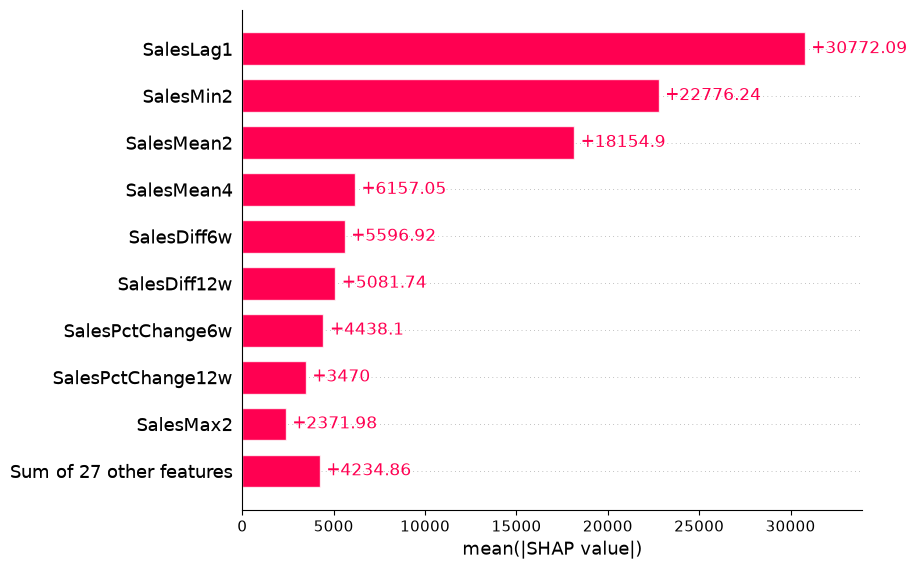

In [129]:
shap.plots.bar(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week6_bar.png')
plt.show()

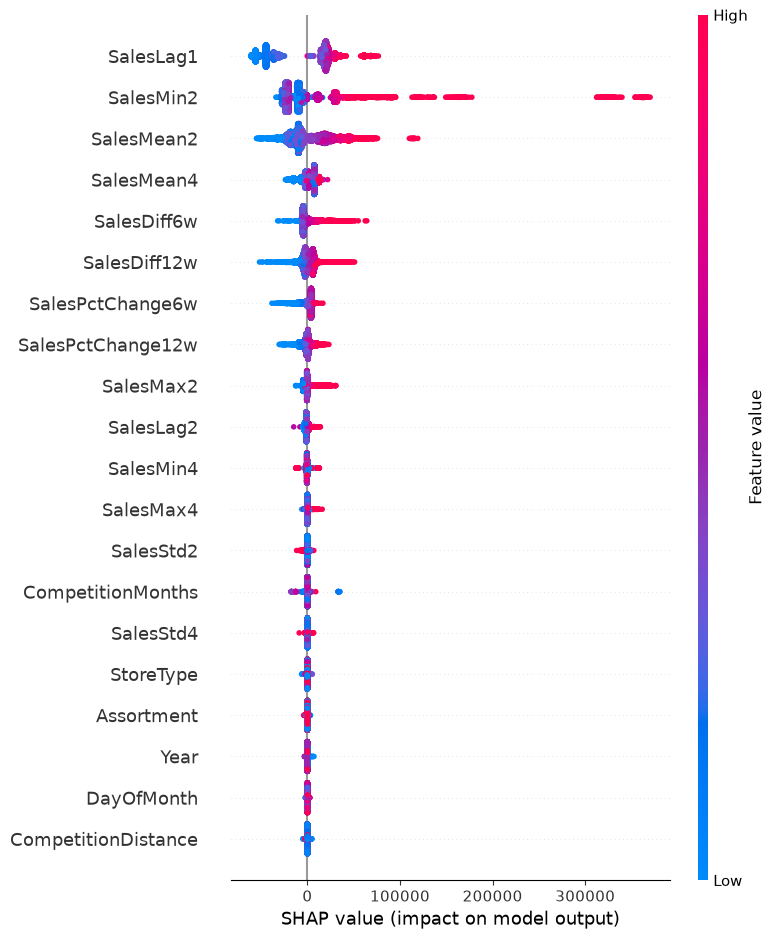

In [130]:
shap.summary_plot(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week6_summary.png')
plt.show()

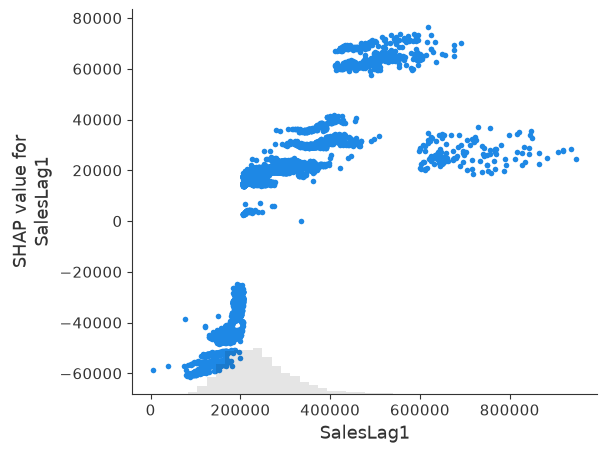

In [131]:
shap.plots.scatter(shap_values_cb[:, "SalesLag1"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week6_scatter_saleslag1.png')
plt.show()

In [132]:
mlflow.end_run()

🏃 View run cb_week6 at: http://localhost:5000/#/experiments/1/runs/a98054de07b1412bb7a35e468f841f5f
🧪 View experiment at: http://localhost:5000/#/experiments/1


LightGBM

In [133]:
mlflow.start_run(run_id=lgbm_week2_run_id)

<ActiveRun: >

In [134]:
importance_df_lgbm_week2 = pd.DataFrame({
    'feature_name': lgbm_model_week2.feature_name_,
    'importance': lgbm_model_week2.feature_importances_ / np.sum(lgbm_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

mlflow.log_table(data=importance_df_lgbm_week2, artifact_file='feature_importance/lgbm_week2_top5.json')
importance_df_lgbm_week2

,feature_name,importance
0,SalesLag2,0.157783
1,SalesPctChange4w,0.119917
2,SalesDiff4w,0.110107
3,SalesPctChange12w,0.056697
4,SalesDiff12w,0.047576


In [135]:
shap_values_raw = lgbm_model_week2.predict(lgbm_train_week2, pred_contrib=True)

expected_value = shap_values_raw[:, -1].mean()
shap_values_to_plot = shap_values_raw[:, :-1]

shap_exp = shap.Explanation(
    values=shap_values_to_plot,
    base_values=expected_value,
    data=lgbm_train_week2.to_numpy(),
    feature_names=lgbm_train_week2.columns.tolist()
)

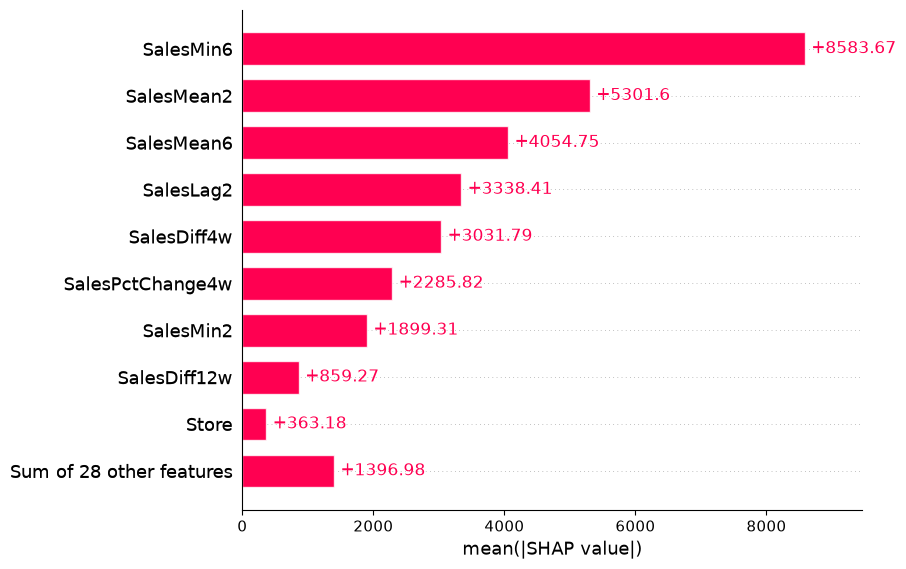

In [136]:
shap.plots.bar(shap_exp, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_bar.png')
plt.show()

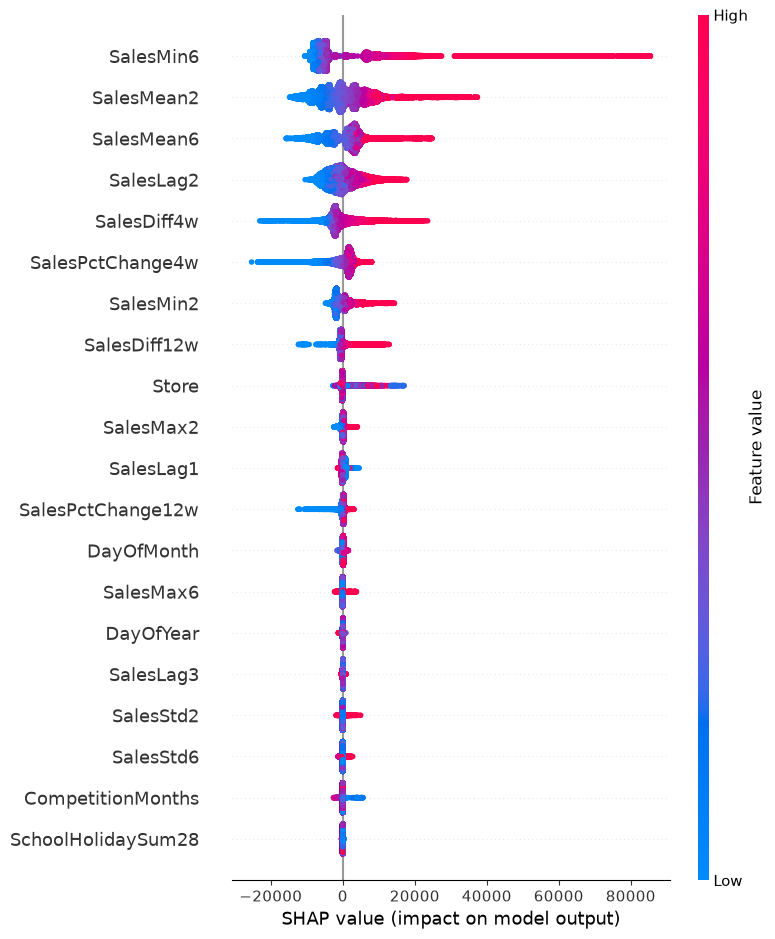

In [137]:
shap.summary_plot(shap_exp, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_summary.png')
plt.show()

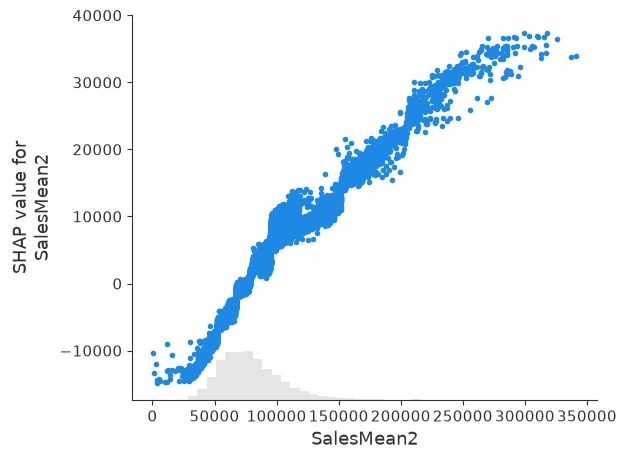

In [138]:
shap.plots.scatter(shap_exp[:, "SalesMean2"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_scatter_saleslag2.png')
plt.show()

In [139]:
mlflow.end_run()

🏃 View run lgbm_week2 at: http://localhost:5000/#/experiments/1/runs/a121edbc795d43f98fdef4c55b68304a
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [140]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [141]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Удаление выбросов

In [142]:
open_df = train_df[train_df['Open'] == 1]
q1 = open_df.groupby('Store')['Sales'].quantile(0.25)
q3 = open_df.groupby('Store')['Sales'].quantile(0.75)
iqr = q3 - q1

In [143]:
lower_bound = train_df['Store'].map(q1 - 1.5 * iqr)
upper_bound = train_df['Store'].map(q3 + 1.5 * iqr)
is_outlier = (train_df['Open'] == 1) & ((train_df['Sales'] < lower_bound) | (train_df['Sales'] > upper_bound))
print(f"В датасете всего {train_df[is_outlier].shape[0]} выбросов. Или в процентах: {train_df[is_outlier].shape[0]/train_df.shape[0]:.2%}")

В датасете всего 15285 выбросов. Или в процентах: 1.77%


In [144]:
train_df = train_df[~is_outlier]

# Пропуски в данных

In [145]:
missing = train_df.isna().sum()
missing[missing > 0]

CompetitionDistance      2189
CompetitionMonths      270396
PromoMean7               7697
PromoMean28             31059
SchoolHolidaySum7        7697
SchoolHolidaySum28      31059
dtype: int64

In [146]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [147]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

## IterativeImputer / BayesianRidge

In [148]:
br_impute = IterativeImputer(max_iter=3, random_state=42)
X_train_br = pd.DataFrame(scaler.inverse_transform(br_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_br = pd.DataFrame(scaler.inverse_transform(br_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

In [149]:
X_train_br['CompetitionMonths'] = X_train_br['CompetitionMonths'].astype(int)
X_train_br['SchoolHolidaySum7'] = X_train_br['SchoolHolidaySum7'].astype(int)
X_train_br['SchoolHolidaySum28'] = X_train_br['SchoolHolidaySum28'].astype(int)

X_val_br['CompetitionMonths'] = X_val_br['CompetitionMonths'].astype(int)
X_val_br['SchoolHolidaySum7'] = X_val_br['SchoolHolidaySum7'].astype(int)
X_val_br['SchoolHolidaySum28'] = X_val_br['SchoolHolidaySum28'].astype(int)

In [150]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [151]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [152]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
wape = wmape(actual, predicted)

print("R^2 score =", r2)
print("MSE score =", mse)
print("RMSE score =", rmse)
print("WAPE score =", wape)

R^2 score = 0.9260165709670056
MSE score = 1153772.0570965793
RMSE score = 1074.137820345499
WAPE score = 11.296512463681108


Подготовка данных

In [153]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [154]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

In [155]:
with mlflow.start_run(run_name='preprocessing_no_outliers') as prep_run_no:
    mlflow.sklearn.log_model(scaler, 'scaler', serialization_format='pickle')
    mlflow.sklearn.log_model(br_impute, 'imputer', serialization_format='pickle')
    mlflow.log_dict(
        {
            'cat_features': cat_features,
            'num_features': list(num_features),
            'target_columns': list(target_columns),
            'agg_dict': {k: (v if isinstance(v, str) else str(v)) for k, v in agg_dict.items()},
            'cutoff': str(cutoff),
        },
        'pipeline_metadata.json'
    )
    preprocessing_no_outliers_run_id = prep_run_no.info.run_id

2026/07/26 09:46:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 09:46:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 09:46:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 09:46:57 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/07/26 09:46:57 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 09:46:57 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/0

🏃 View run preprocessing_no_outliers at: http://localhost:5000/#/experiments/1/runs/7a46f3afe6784aae9dc872b3a3a9c8a6
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Обучение

In [156]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

Предсказание по неделе вперед

In [157]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [158]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [159]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [160]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-26 09:47:13,417] A new study created in memory with name: no-name-2776a470-f75f-4f0e-83c0-2feda66a650d
[I 2026-07-26 09:48:46,921] Trial 0 finished with value: 1.9235731317002498 and parameters: {'learning_rate': 0.0019304497380526456, 'n_estimators': 1905, 'min_child_samples': 391, 'num_leaves': 970, 'reg_lambda': 0.37841781569106087, 'colsample_bytree': 0.6470531989232042}. Best is trial 0 with value: 1.9235731317002498.
[I 2026-07-26 09:50:34,972] Trial 1 finished with value: 0.8508524914308171 and parameters: {'learning_rate': 0.03281602389099991, 'n_estimators': 2346, 'min_child_samples': 429, 'num_leaves': 449, 'reg_lambda': 0.18084342220268956, 'colsample_bytree': 0.640750301377998}. Best is trial 1 with value: 0.8508524914308171.
[I 2026-07-26 09:51:37,057] Trial 2 finished with value: 0.8785054898509127 and parameters: {'learning_rate': 0.02820782554059093, 'n_estimators': 699, 'min_child_samples': 340, 'num_leaves': 263, 'reg_lambda': 0.0023211105716457086, 'colsam

In [161]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [162]:
with mlflow.start_run(run_name='lgbm_week1 no_outliers') as run:
    mlflow.log_params(study_lgbm_week1.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week1)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week1, 'model')
    lgbm_week1_no_run_id = run.info.run_id

2026/07/26 10:10:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 10:10:07 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 10:10:09 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 10:10:09 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 10:10:09 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 10:10:09 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 10:10:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week1 no_outliers at: http://localhost:5000/#/experiments/1/runs/22a3141ae7e94ee6a20beb1496edcbea
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [163]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-26 10:10:11,182] A new study created in memory with name: no-name-d67e7f94-85e3-4fd1-829b-e7dc9bf41361
[I 2026-07-26 10:13:21,457] Trial 0 finished with value: 0.845293732046821 and parameters: {'learning_rate': 0.09705610368544146, 'iterations': 1143, 'depth': 7, 'bagging_temperature': 1.7900070887379915, 'l2_leaf_reg': 6.322197038500771, 'random_strength': 4.939034839918431, 'subsample': 0.6046736178315835}. Best is trial 0 with value: 0.845293732046821.
[I 2026-07-26 10:15:07,307] Trial 1 finished with value: 1.962587634787537 and parameters: {'learning_rate': 0.03322199566374363, 'iterations': 533, 'depth': 6, 'bagging_temperature': 4.468092252436703, 'l2_leaf_reg': 6.076032577521903, 'random_strength': 2.900636684342437, 'subsample': 0.9288309050061545}. Best is trial 0 with value: 0.845293732046821.
[I 2026-07-26 10:18:56,203] Trial 2 finished with value: 0.6031784476380757 and parameters: {'learning_rate': 0.22205805107648452, 'iterations': 1067, 'depth': 7, 'bagging_

In [164]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [165]:
with mlflow.start_run(run_name='cb_week1 no_outliers') as run:
    mlflow.log_params(study_cb_week1.best_params)
    mlflow.log_metric('WAPE', score_cb_week1)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 1)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week1, 'model')
    cb_week1_no_run_id = run.info.run_id

2026/07/26 11:06:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 11:06:20 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:06:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:06:21 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 11:06:21 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 11:06:21 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 11:06:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week1 no_outliers at: http://localhost:5000/#/experiments/1/runs/063a1ffa722045aa83957cd239481674
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 2 недели

In [166]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [167]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [168]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [169]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-26 11:06:27,624] A new study created in memory with name: no-name-be47bd7d-d34c-4cf6-83ef-c5eb4aefd068
[I 2026-07-26 11:06:58,744] Trial 0 finished with value: 1.0209619743834935 and parameters: {'learning_rate': 0.22276706310115596, 'n_estimators': 1118, 'min_child_samples': 410, 'num_leaves': 920, 'reg_lambda': 0.001354654348438564, 'colsample_bytree': 0.5858947558452355}. Best is trial 0 with value: 1.0209619743834935.
[I 2026-07-26 11:07:25,600] Trial 1 finished with value: 1.0565638035369587 and parameters: {'learning_rate': 0.1995567628711032, 'n_estimators': 640, 'min_child_samples': 466, 'num_leaves': 449, 'reg_lambda': 1.7862458749593197, 'colsample_bytree': 0.8452898385364345}. Best is trial 0 with value: 1.0209619743834935.
[I 2026-07-26 11:07:57,183] Trial 2 finished with value: 2.6302150112746 and parameters: {'learning_rate': 0.9255994747355802, 'n_estimators': 683, 'min_child_samples': 191, 'num_leaves': 271, 'reg_lambda': 0.013338181333785532, 'colsample_bytr

In [170]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [171]:
with mlflow.start_run(run_name='lgbm_week2 no_outliers') as run:
    mlflow.log_params(study_lgbm_week2.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week2)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week2, 'model')
    lgbm_week2_no_run_id = run.info.run_id

2026/07/26 11:21:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 11:21:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:21:10 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:21:10 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 11:21:10 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 11:21:10 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 11:21:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week2 no_outliers at: http://localhost:5000/#/experiments/1/runs/1252f18bccba46019e163422fd9902a3
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [172]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-26 11:21:13,940] A new study created in memory with name: no-name-e3a74533-4c4b-494c-8569-690d7583920c
[I 2026-07-26 11:22:32,880] Trial 0 finished with value: 0.6507362745924462 and parameters: {'learning_rate': 0.26454365075780284, 'iterations': 607, 'depth': 6, 'bagging_temperature': 0.6250427503061706, 'l2_leaf_reg': 6.797564001482197, 'random_strength': 2.5390175880818533, 'subsample': 0.5764351466185982}. Best is trial 0 with value: 0.6507362745924462.
[I 2026-07-26 11:23:41,789] Trial 1 finished with value: 22.014566826823547 and parameters: {'learning_rate': 0.001044415861322607, 'iterations': 304, 'depth': 9, 'bagging_temperature': 7.430949918738063, 'l2_leaf_reg': 6.583095646196289, 'random_strength': 2.3515802272073127, 'subsample': 0.6538360409038846}. Best is trial 0 with value: 0.6507362745924462.
[I 2026-07-26 11:24:54,171] Trial 2 finished with value: 1.5535726903076634 and parameters: {'learning_rate': 0.010326899808244656, 'iterations': 721, 'depth': 5, 'ba

In [173]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [174]:
with mlflow.start_run(run_name='cb_week2 no_outliers') as run:
    mlflow.log_params(study_cb_week2.best_params)
    mlflow.log_metric('WAPE', score_cb_week2)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 2)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week2, 'model')
    cb_week2_no_run_id = run.info.run_id

2026/07/26 11:53:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 11:53:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:53:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:53:15 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 11:53:15 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 11:53:15 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 11:53:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week2 no_outliers at: http://localhost:5000/#/experiments/1/runs/8b582e45c33f4411b028fe26a78b7e74
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 4 недели


In [175]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [176]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [177]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [178]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-26 11:53:27,731] A new study created in memory with name: no-name-afceb592-c062-4e04-8e2b-1a4ec70ffdae
[I 2026-07-26 11:53:48,799] Trial 0 finished with value: 1.2644041258984275 and parameters: {'learning_rate': 0.0017059892503087997, 'n_estimators': 2499, 'min_child_samples': 192, 'num_leaves': 253, 'reg_lambda': 4.426330097694652, 'colsample_bytree': 0.9094728048657634}. Best is trial 0 with value: 1.2644041258984275.
[I 2026-07-26 11:54:05,072] Trial 1 finished with value: 1.2627616996534055 and parameters: {'learning_rate': 0.04759789739007569, 'n_estimators': 2406, 'min_child_samples': 483, 'num_leaves': 843, 'reg_lambda': 0.00181486768823149, 'colsample_bytree': 0.6099857176750321}. Best is trial 1 with value: 1.2627616996534055.
[I 2026-07-26 11:54:18,417] Trial 2 finished with value: 1.6116743496089252 and parameters: {'learning_rate': 0.005852497616882083, 'n_estimators': 756, 'min_child_samples': 325, 'num_leaves': 799, 'reg_lambda': 6.5739181150782136, 'colsample

In [179]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [180]:
with mlflow.start_run(run_name='lgbm_week4 no_outliers') as run:
    mlflow.log_params(study_lgbm_week4.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week4)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week4, 'model')
    lgbm_week4_no_run_id = run.info.run_id

2026/07/26 11:58:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 11:58:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:58:32 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 11:58:32 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 11:58:32 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 11:58:32 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 11:58:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week4 no_outliers at: http://localhost:5000/#/experiments/1/runs/df84a3f871794eb9a024e732f64e6d0a
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [181]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-26 11:58:33,517] A new study created in memory with name: no-name-45d742d1-2d0b-4faf-816a-38293d77c47e
[I 2026-07-26 11:59:58,379] Trial 0 finished with value: 1.2889010048082163 and parameters: {'learning_rate': 0.05993951703692413, 'iterations': 369, 'depth': 10, 'bagging_temperature': 8.172490664893791, 'l2_leaf_reg': 4.6225377432672206, 'random_strength': 7.852944828852387, 'subsample': 0.8673922020846413}. Best is trial 0 with value: 1.2889010048082163.
[I 2026-07-26 12:00:47,895] Trial 1 finished with value: 6.777467176627037 and parameters: {'learning_rate': 0.0027254671542640547, 'iterations': 692, 'depth': 4, 'bagging_temperature': 0.45947080836740817, 'l2_leaf_reg': 9.10839478561262, 'random_strength': 4.648620354317324, 'subsample': 0.6242609853820673}. Best is trial 0 with value: 1.2889010048082163.
[I 2026-07-26 12:02:08,830] Trial 2 finished with value: 1.1175702085413604 and parameters: {'learning_rate': 0.20744009775679884, 'iterations': 329, 'depth': 10, 'ba

In [182]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [183]:
with mlflow.start_run(run_name='cb_week4 no_outliers') as run:
    mlflow.log_params(study_cb_week4.best_params)
    mlflow.log_metric('WAPE', score_cb_week4)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 4)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week4, 'model')
    cb_week4_no_run_id = run.info.run_id

2026/07/26 12:28:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 12:28:12 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:28:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:28:13 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 12:28:13 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 12:28:13 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 12:28:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week4 no_outliers at: http://localhost:5000/#/experiments/1/runs/1d9b036a1559433095011a7bde7a654f
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 6 недель

In [184]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [185]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [186]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [187]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-26 12:28:19,234] A new study created in memory with name: no-name-b3072d56-a33f-4703-9955-df7ff2599dd7
[I 2026-07-26 12:28:28,726] Trial 0 finished with value: 1.2601417771245662 and parameters: {'learning_rate': 0.02683932022004859, 'n_estimators': 1057, 'min_child_samples': 246, 'num_leaves': 348, 'reg_lambda': 2.0497881674768585, 'colsample_bytree': 0.5948225979447395}. Best is trial 0 with value: 1.2601417771245662.
[I 2026-07-26 12:28:37,198] Trial 1 finished with value: 2.279333093433605 and parameters: {'learning_rate': 0.5674645459946502, 'n_estimators': 1081, 'min_child_samples': 366, 'num_leaves': 959, 'reg_lambda': 0.2549962703301864, 'colsample_bytree': 0.6801462665060202}. Best is trial 0 with value: 1.2601417771245662.
[I 2026-07-26 12:28:46,900] Trial 2 finished with value: 2.586070054213999 and parameters: {'learning_rate': 0.14735772126068214, 'n_estimators': 2055, 'min_child_samples': 478, 'num_leaves': 405, 'reg_lambda': 4.050930990007162, 'colsample_bytre

In [188]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [189]:
with mlflow.start_run(run_name='lgbm_week6 no_outliers') as run:
    mlflow.log_params(study_lgbm_week6.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week6)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week6, 'model')
    lgbm_week6_no_run_id = run.info.run_id

2026/07/26 12:31:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 12:31:33 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:31:34 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:31:34 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 12:31:34 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 12:31:34 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 12:31:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week6 no_outliers at: http://localhost:5000/#/experiments/1/runs/f8b887f472d64824b60c26ff9b4cf790
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [190]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-26 12:31:35,965] A new study created in memory with name: no-name-5b915b46-4ec0-4ce4-82b9-287c6db331cc
[I 2026-07-26 12:33:03,828] Trial 0 finished with value: 0.6814284744110995 and parameters: {'learning_rate': 0.04796016267762905, 'iterations': 808, 'depth': 7, 'bagging_temperature': 9.283762109440293, 'l2_leaf_reg': 6.796329563633288, 'random_strength': 0.04744704578079295, 'subsample': 0.9842744951466426}. Best is trial 0 with value: 0.6814284744110995.
[I 2026-07-26 12:35:23,145] Trial 1 finished with value: 1.058304010777175 and parameters: {'learning_rate': 0.5132693099322888, 'iterations': 846, 'depth': 9, 'bagging_temperature': 4.998737240573405, 'l2_leaf_reg': 4.918998230742103, 'random_strength': 2.9549689951427682, 'subsample': 0.5030961281099655}. Best is trial 0 with value: 0.6814284744110995.
[I 2026-07-26 12:36:51,769] Trial 2 finished with value: 1.1542325285737705 and parameters: {'learning_rate': 0.007688797907140047, 'iterations': 1120, 'depth': 5, 'bagg

In [191]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [192]:
with mlflow.start_run(run_name='cb_week6 no_outliers') as run:
    mlflow.log_params(study_cb_week6.best_params)
    mlflow.log_metric('WAPE', score_cb_week6)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 6)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week6, 'model')
    cb_week6_no_run_id = run.info.run_id

2026/07/26 12:56:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 12:56:23 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:56:23 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:56:23 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 12:56:24 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 12:56:24 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 12:56:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week6 no_outliers at: http://localhost:5000/#/experiments/1/runs/23be4bbc63844aaba4dd79094da1ec02
🧪 View experiment at: http://localhost:5000/#/experiments/1


Предсказание по группировке 12 недель

In [193]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [194]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [195]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [196]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-26 12:56:30,630] A new study created in memory with name: no-name-23aff8a6-d79a-4ea8-973a-c6f7bc84f2db
[I 2026-07-26 12:56:34,239] Trial 0 finished with value: 8.623555985559165 and parameters: {'learning_rate': 0.009729229064453514, 'n_estimators': 798, 'min_child_samples': 376, 'num_leaves': 509, 'reg_lambda': 4.748638059770155, 'colsample_bytree': 0.6058018959498512}. Best is trial 0 with value: 8.623555985559165.
[I 2026-07-26 12:56:38,197] Trial 1 finished with value: 10.34761447052342 and parameters: {'learning_rate': 0.15585174421522838, 'n_estimators': 980, 'min_child_samples': 499, 'num_leaves': 730, 'reg_lambda': 0.0011472121274259206, 'colsample_bytree': 0.8775103967460203}. Best is trial 0 with value: 8.623555985559165.
[I 2026-07-26 12:56:42,154] Trial 2 finished with value: 12.519223122627974 and parameters: {'learning_rate': 0.0011310306200672739, 'n_estimators': 653, 'min_child_samples': 88, 'num_leaves': 807, 'reg_lambda': 0.0033289638856899796, 'colsample_b

In [197]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [198]:
with mlflow.start_run(run_name='lgbm_week12 no_outliers') as run:
    mlflow.log_params(study_lgbm_week12.best_params)
    mlflow.log_metric('WAPE', score_lgbm_week12)
    mlflow.set_tag('model_type', 'lgbm')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.lightgbm.log_model(lgbm_model_week12, 'model')
    lgbm_week12_no_run_id = run.info.run_id

2026/07/26 12:57:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 12:57:47 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:57:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 12:57:48 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 12:57:48 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 12:57:48 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 12:57:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run lgbm_week12 no_outliers at: http://localhost:5000/#/experiments/1/runs/39e4b549412e4414868bcc278b4b3c81
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [199]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-26 12:57:49,331] A new study created in memory with name: no-name-3d18423d-21f1-4ceb-8f65-2ac4b31edc52
[I 2026-07-26 12:59:05,021] Trial 0 finished with value: 2.043545252142776 and parameters: {'learning_rate': 0.5199057349446663, 'iterations': 860, 'depth': 7, 'bagging_temperature': 1.157213444690245, 'l2_leaf_reg': 4.866689210624619, 'random_strength': 2.6054900827074756, 'subsample': 0.7940974247871437}. Best is trial 0 with value: 2.043545252142776.
[I 2026-07-26 13:00:08,683] Trial 1 finished with value: 9.534130433454315 and parameters: {'learning_rate': 0.0012514104210017058, 'iterations': 998, 'depth': 5, 'bagging_temperature': 5.753153209594571, 'l2_leaf_reg': 4.83051862853983, 'random_strength': 0.7499845699542762, 'subsample': 0.6323194710345839}. Best is trial 0 with value: 2.043545252142776.
[I 2026-07-26 13:00:31,898] Trial 2 finished with value: 1.2717104345046253 and parameters: {'learning_rate': 0.028291833112710142, 'iterations': 339, 'depth': 5, 'bagging_

In [200]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [201]:
with mlflow.start_run(run_name='cb_week12 no_outliers') as run:
    mlflow.log_params(study_cb_week12.best_params)
    mlflow.log_metric('WAPE', score_cb_week12)
    mlflow.set_tag('model_type', 'cb')
    mlflow.set_tag('n_weeks', 12)
    mlflow.set_tag('outliers_removed', True)
    mlflow.set_tag('preprocessing_run_id', preprocessing_no_outliers_run_id)
    mlflow.catboost.log_model(cb_model_week12, 'model')
    cb_week12_no_run_id = run.info.run_id

2026/07/26 13:18:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/26 13:18:44 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 13:18:45 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Project
2026/07/26 13:18:45 INFO mlflow.utils.environment: Detected uv project at c:\Project. Attempting to export requirements via 'uv export'.
2026/07/26 13:18:45 INFO mlflow.utils.uv_utils: Exported 143 dependencies via uv
2026/07/26 13:18:45 INFO mlflow.utils.environment: Successfully exported 143 requirements from uv project. Skipping package capture based inference.
2026/07/26 13:18:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run cb_week12 no_outliers at: http://localhost:5000/#/experiments/1/runs/93da924e3581421f8b0b188ebd206b13
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Сравнение качества

In [202]:
comparison_no_outliers = pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

comparison_no_outliers

,WAPE score
CatBoost week2,0.492764
CatBoost week1,0.518355
LGBM week2,0.553172
LGBM week6,0.617487
CatBoost week4,0.638561
CatBoost week6,0.654466
LGBM week4,0.661441
LGBM week1,0.818148
CatBoost week12,1.033705
LGBM week12,2.533812


In [203]:
with mlflow.start_run(run_name='comparison_no_outliers'):
    mlflow.log_table(data=comparison_no_outliers.reset_index(), artifact_file='comparison/no_outliers_wape.json')

🏃 View run comparison_no_outliers at: http://localhost:5000/#/experiments/1/runs/fe8836f96ff84612874513292f48d924
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Feature Importance

CatBoost

In [204]:
mlflow.start_run(run_id=cb_week2_no_run_id)

<ActiveRun: >

In [205]:
importance_df_cb_week2_no = pd.DataFrame({
    'feature_name': cb_model_week2.feature_names_,
    'importance': cb_model_week2.feature_importances_ / np.sum(cb_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

importance_df_cb_week2_no

,feature_name,importance
0,SalesMean6,0.510225
1,SalesMin6,0.095482
2,SalesLag2,0.079565
3,SalesMean2,0.067700
4,SalesMax6,0.051383


In [206]:
mlflow.log_table(data=importance_df_cb_week2_no, artifact_file='feature_importance/cb_week2_no_outliers_top5.json')

In [207]:
explainer_cb = shap.TreeExplainer(cb_model_week2)
shap_values_cb = explainer_cb(cb_train_week2)

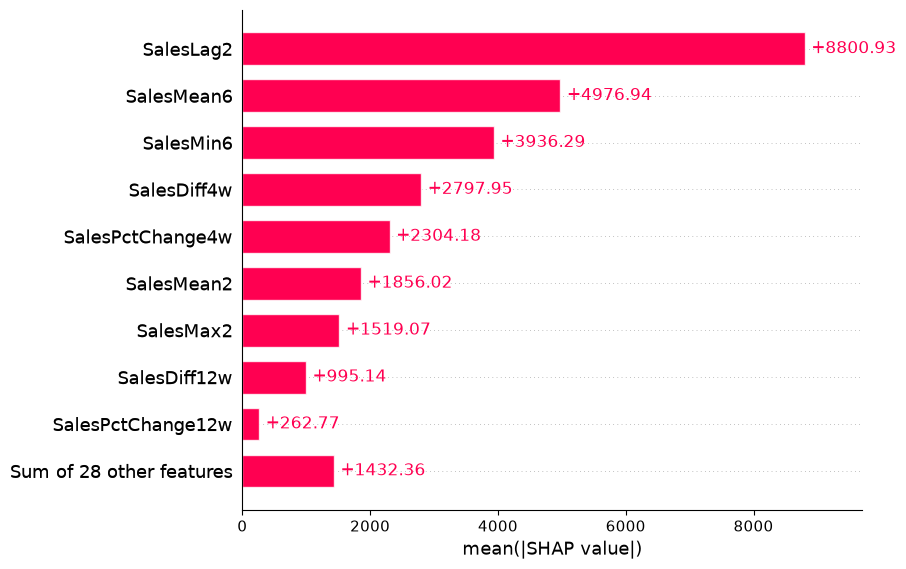

In [208]:
shap.plots.bar(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_no_outliers_bar.png')
plt.show()

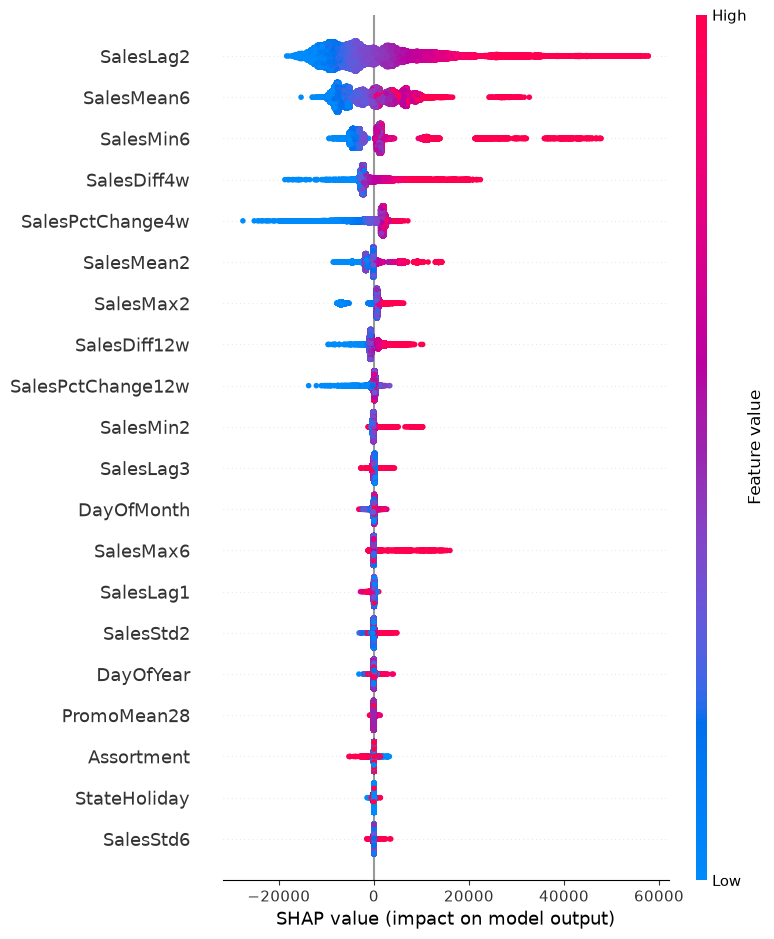

In [209]:
shap.summary_plot(shap_values_cb, show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_no_outliers_summary.png')
plt.show()

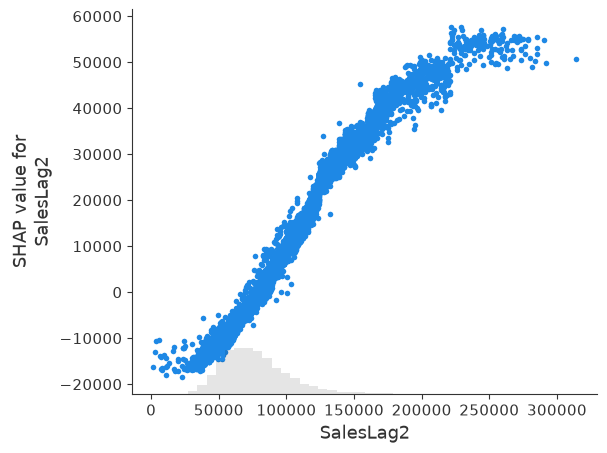

In [210]:
shap.plots.scatter(shap_values_cb[:, "SalesLag2"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/cb_week2_no_outliers_scatter_saleslag2.png')
plt.show()

In [211]:
mlflow.end_run()

🏃 View run cb_week2 no_outliers at: http://localhost:5000/#/experiments/1/runs/8b582e45c33f4411b028fe26a78b7e74
🧪 View experiment at: http://localhost:5000/#/experiments/1


LightGBM

In [212]:
mlflow.start_run(run_id=lgbm_week2_no_run_id)

<ActiveRun: >

In [213]:
importance_df_lgbm_week2_no = pd.DataFrame({
    'feature_name': lgbm_model_week2.feature_name_,
    'importance': lgbm_model_week2.feature_importances_ / np.sum(lgbm_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

importance_df_lgbm_week2_no

,feature_name,importance
0,SalesPctChange4w,0.075345
1,SalesDiff4w,0.072920
2,Store,0.072292
3,SalesStd6,0.070066
4,SalesStd2,0.070036


In [214]:
mlflow.log_table(data=importance_df_lgbm_week2_no, artifact_file='feature_importance/lgbm_week2_no_outliers_top5.json')

In [ ]:
shap_values_raw = lgbm_model_week2.predict(lgbm_train_week2, pred_contrib=True)

expected_value = shap_values_raw[:, -1].mean()
shap_values_to_plot = shap_values_raw[:, :-1]

shap_exp = shap.Explanation(
    values=shap_values_to_plot,
    base_values=expected_value,
    data=lgbm_train_week2.to_numpy(),
    feature_names=lgbm_train_week2.columns.tolist()
)

In [ ]:
shap.plots.bar(shap_exp, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_no_outliers_bar.png')
plt.show()

In [ ]:
shap.summary_plot(shap_exp, show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_no_outliers_summary.png')
plt.show()

In [ ]:
shap.plots.scatter(shap_exp[:, "Store"], show=False)
mlflow.log_figure(plt.gcf(), 'shap/lgbm_week2_no_outliers_scatter_store.png')
plt.show()

In [ ]:
mlflow.end_run()